# Bluestock MF Analytics — Day 6: Advanced Analytics + Risk Metrics

Historical VaR/CVaR, rolling Sharpe, investor cohort analysis, SIP
continuity/at-risk flagging, a simple risk-matched fund recommender, and
sector concentration (HHI) — all computed from the cleaned Day 2 data and
the Day 4 performance outputs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("..")
TRADING_DAYS = 252

nav = pd.read_csv("../data/processed/clean_nav.csv", parse_dates=["date"], dtype={"amfi_code": str})
fund_master = pd.read_csv("../data/raw/01_fund_master.csv", dtype={"amfi_code": str})
tx = pd.read_csv("../data/processed/clean_transactions.csv", parse_dates=["transaction_date"], dtype={"amfi_code": str})
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv", dtype={"amfi_code": str})
scorecard = pd.read_csv("../fund_scorecard.csv", dtype={"amfi_code": str})  # from Day 4

nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav = nav.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")

print(f"NAV: {nav.shape}, Transactions: {tx.shape}, Holdings: {holdings.shape}")


NAV: (46000, 7), Transactions: (32778, 13), Holdings: (322, 8)


## Task 1 — Historical VaR (95%) and CVaR
`VaR_95 = 5th percentile of daily returns` (the loss threshold breached on
the worst 5% of days). `CVaR_95 = mean of returns below that threshold`
(the average loss on those worst days — always more negative than VaR).

In [2]:
var_rows = []
for code_, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    if len(r) < 30:
        continue
    var_95 = r.quantile(0.05)
    cvar_95 = r[r <= var_95].mean()
    var_rows.append({"amfi_code": code_, "var_95_pct": var_95 * 100, "cvar_95_pct": cvar_95 * 100})

var_df = pd.DataFrame(var_rows)
var_df = var_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
var_df = var_df[["amfi_code", "scheme_name", "category", "var_95_pct", "cvar_95_pct"]]
var_df = var_df.sort_values("var_95_pct")  # most negative (highest risk) first

var_df.to_csv(OUT_DIR / "var_cvar_report.csv", index=False)
print(f"Saved var_cvar_report.csv ({len(var_df)} funds)")

print("\n5 highest-VaR (riskiest) funds:")
print(var_df.head(5).to_string(index=False))


Saved var_cvar_report.csv (40 funds)

5 highest-VaR (riskiest) funds:
amfi_code                                    scheme_name category  var_95_pct  cvar_95_pct
   119599      SBI Small Cap Fund - Direct Plan - Growth   Equity   -2.685944    -3.238412
   119095         Axis Small Cap Fund - Regular - Growth   Equity   -2.618842    -3.166729
   101207         ABSL Small Cap Fund - Regular - Growth   Equity   -2.602125    -3.245906
   118634 Nippon India Small Cap Fund - Regular - Growth   Equity   -2.543811    -3.230407
   119598     SBI Small Cap Fund - Regular Plan - Growth   Equity   -2.450705    -3.059526


## Task 2 — Rolling 90-day Sharpe Ratio
`rolling_sharpe = returns.rolling(90).mean() / returns.rolling(90).std() × √252`,
plotted over time for the 5 largest funds by AUM.

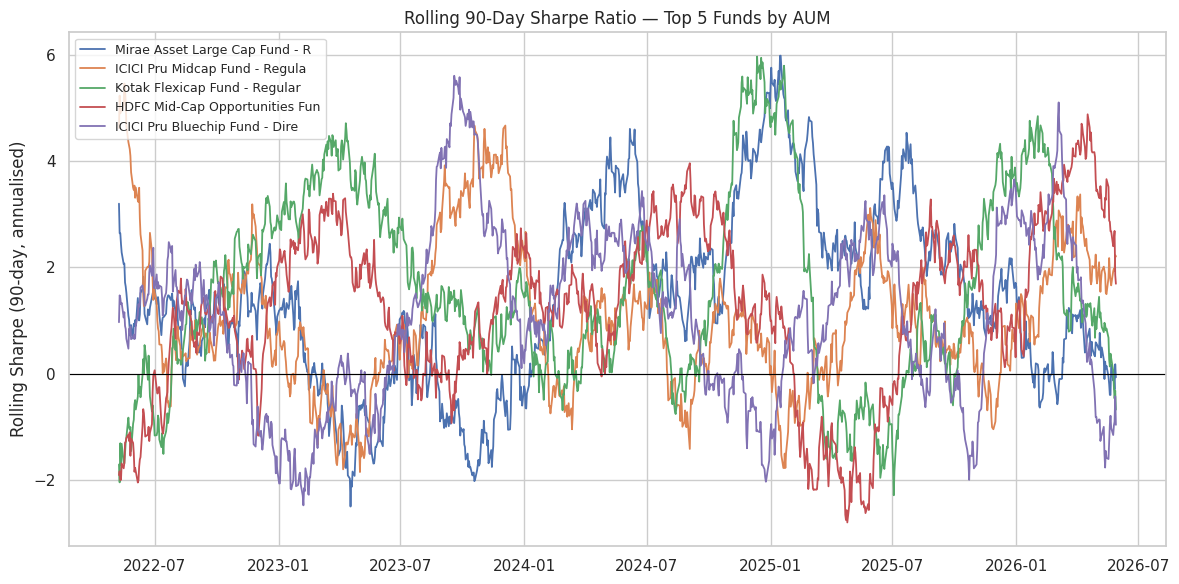

In [3]:
RF_DAILY = 0.065 / TRADING_DAYS  # consistent with Day 4's Rf assumption
top5 = scorecard.nlargest(5, "score")["amfi_code"].tolist() if "aum_crore" not in scorecard.columns \
       else scorecard.merge(pd.read_csv("../data/processed/clean_performance.csv", dtype={"amfi_code":str})[["amfi_code","aum_crore"]], on="amfi_code").nlargest(5, "aum_crore")["amfi_code"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
for code_ in top5:
    g = nav[nav["amfi_code"] == code_].sort_values("date").copy()
    g["rolling_sharpe"] = (
        (g["daily_return"] - RF_DAILY).rolling(90).mean()
        / g["daily_return"].rolling(90).std()
        * np.sqrt(TRADING_DAYS)
    )
    name = g["scheme_name"].iloc[0]
    ax.plot(g["date"], g["rolling_sharpe"], label=name[:30], linewidth=1.3)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds by AUM")
ax.set_ylabel("Rolling Sharpe (90-day, annualised)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(CHART_DIR / "15_rolling_sharpe_chart.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT_DIR / "rolling_sharpe_chart.png", dpi=150, bbox_inches="tight")  # also at root per deliverables spec
plt.show()


## Task 3 — Investor Cohort Analysis
Investors grouped by the year of their *first* transaction. For each
cohort: average SIP amount, total amount invested (SIP + Lumpsum), and
the most-preferred fund.

In [4]:
first_tx = tx.groupby("investor_id")["transaction_date"].min().rename("first_tx_date").reset_index()
first_tx["cohort_year"] = first_tx["first_tx_date"].dt.year
tx_cohort = tx.merge(first_tx[["investor_id", "cohort_year"]], on="investor_id")

sip_only = tx_cohort[tx_cohort["transaction_type"] == "SIP"]
invested = tx_cohort[tx_cohort["transaction_type"].isin(["SIP", "Lumpsum"])]

avg_sip = sip_only.groupby("cohort_year")["amount_inr"].mean().rename("avg_sip_amount")
total_invested = invested.groupby("cohort_year")["amount_inr"].sum().rename("total_invested_inr")

top_fund_per_cohort = (
    tx_cohort.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
    .groupby(["cohort_year", "scheme_name"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .drop_duplicates("cohort_year")
    .set_index("cohort_year")["scheme_name"]
    .rename("top_fund_preference")
)

n_investors = tx_cohort.groupby("cohort_year")["investor_id"].nunique().rename("num_investors")

cohort_summary = pd.concat([n_investors, avg_sip, total_invested, top_fund_per_cohort], axis=1).reset_index()
cohort_summary.to_csv(OUT_DIR / "cohort_analysis.csv", index=False)
cohort_summary


,cohort_year,num_investors,avg_sip_amount,total_invested_inr,top_fund_preference
0,2024,4803,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,13505.209581,18992635,SBI Small Cap Fund - Direct Plan - Growth


## Task 4 — SIP Continuity Analysis
For investors with 6+ SIP transactions: average gap between consecutive
SIP dates. Investors with an average gap > 35 days are flagged "at-risk"
(a monthly SIP should have ~30-day gaps; 35+ suggests missed instalments).

In [5]:
sip_tx = tx[tx["transaction_type"] == "SIP"].sort_values(["investor_id", "transaction_date"])
sip_counts = sip_tx.groupby("investor_id").size()
eligible = sip_counts[sip_counts >= 6].index

gaps = []
for inv_id, g in sip_tx[sip_tx["investor_id"].isin(eligible)].groupby("investor_id"):
    g = g.sort_values("transaction_date")
    avg_gap = g["transaction_date"].diff().dt.days.mean()
    gaps.append({"investor_id": inv_id, "num_sip_tx": len(g), "avg_gap_days": avg_gap})

continuity_df = pd.DataFrame(gaps)
continuity_df["at_risk"] = continuity_df["avg_gap_days"] > 35

continuity_df.to_csv(OUT_DIR / "sip_continuity.csv", index=False)

n_at_risk = continuity_df["at_risk"].sum()
print(f"Investors with 6+ SIP transactions: {len(continuity_df)}")
print(f"Flagged at-risk (avg gap > 35 days): {n_at_risk} ({n_at_risk/len(continuity_df)*100:.1f}%)")
continuity_df.sort_values("avg_gap_days", ascending=False).head(10)


Investors with 6+ SIP transactions: 1362
Flagged at-risk (avg gap > 35 days): 1332 (97.8%)


,investor_id,num_sip_tx,avg_gap_days,at_risk
506,INV001890,6,102.6,True
323,INV001156,6,102.4,True
1188,INV004296,6,102.2,True
910,INV003325,6,101.0,True
150,INV000522,6,100.8,True
183,INV000608,6,100.2,True
576,INV002166,6,99.2,True
503,INV001883,6,99.2,True
380,INV001367,6,99.0,True
406,INV001491,6,98.8,True


## Task 5 — Simple Fund Recommender
Standalone version saved as `recommender.py`. Demonstrated here inline
using the Day 4 fund scorecard's Sharpe ratios. Risk appetite maps the
dataset's 5-level `risk_category` down to Low/Moderate/High — see the
`RISK_BUCKET_MAP` in `recommender.py` for the exact mapping.

In [6]:
import sys
sys.path.insert(0, "..")
from recommender import recommend

for appetite in ["Low", "Moderate", "High"]:
    print(f"\n=== Top 3 funds — '{appetite}' risk appetite ===")
    print(recommend(appetite).to_string(index=False))



=== Top 3 funds — 'Low' risk appetite ===
                                 scheme_name category risk_category  sharpe_ratio  cagr_3yr  expense_ratio_pct
    ICICI Pru Liquid Fund - Regular - Growth     Debt           Low      0.495723  0.073925               0.74
        Kotak Liquid Fund - Regular - Growth     Debt           Low     -0.088747  0.066944               0.60
SBI Magnum Gilt Fund - Regular Plan - Growth     Debt           Low     -0.226575  0.058390               0.77

=== Top 3 funds — 'Moderate' risk appetite ===
                                  scheme_name category   risk_category  sharpe_ratio  cagr_3yr  expense_ratio_pct
Mirae Asset Large Cap Fund - Regular - Growth   Equity        Moderate      1.448291  0.339920               1.46
       Kotak Flexicap Fund - Regular - Growth   Equity Moderately High      1.306744  0.295751               1.45
    SBI Bluechip Fund - Regular Plan - Growth   Equity        Moderate      1.208267  0.304486               1.54

=== Top 

## Task 6 — Sector Concentration (HHI)
`HHI = Σ(weight_i²)` per fund, using sector weights in percentage points
(so HHI ranges roughly 0–10,000; a single-sector fund would score 10,000,
a fund evenly split across 10 sectors would score ~1,000). Only equity
funds have holdings data.

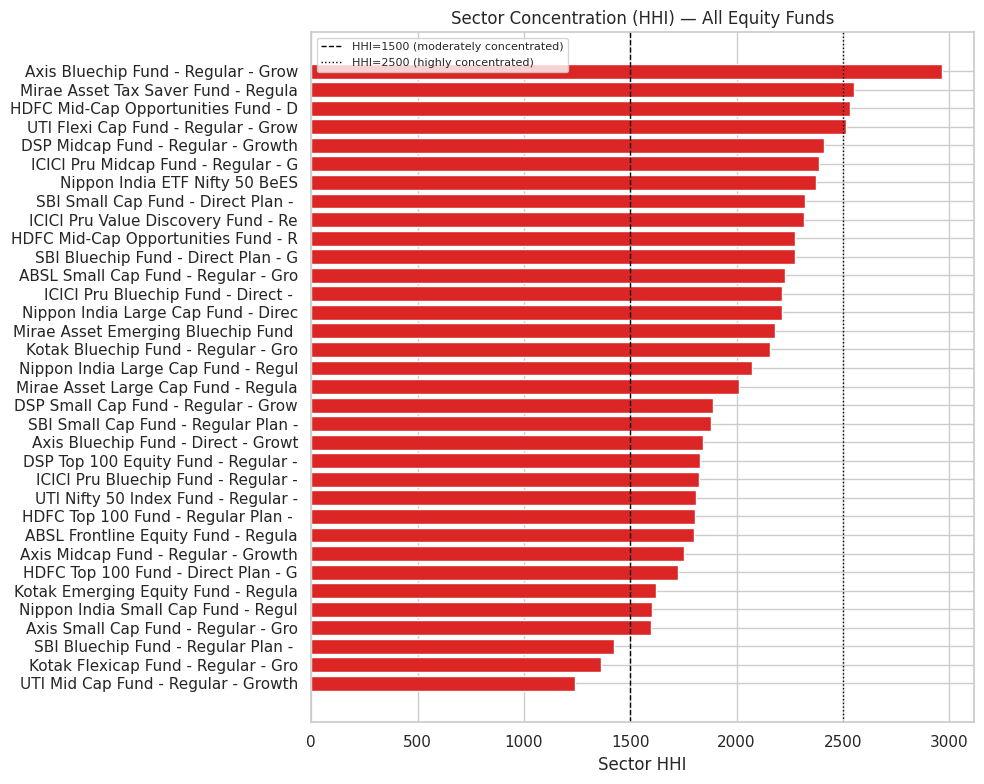

Funds with holdings data: 34 / 34 equity funds


In [7]:
hhi_rows = []
for code_, g in holdings.groupby("amfi_code"):
    sector_weights = g.groupby("sector")["weight_pct"].sum()
    hhi = (sector_weights ** 2).sum()
    hhi_rows.append({"amfi_code": code_, "hhi": hhi, "num_sectors": sector_weights.shape[0]})

hhi_df = pd.DataFrame(hhi_rows)
hhi_df = hhi_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
hhi_df = hhi_df.sort_values("hhi", ascending=False)
hhi_df.to_csv(OUT_DIR / "sector_hhi.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(hhi_df["scheme_name"].str.slice(0, 35), hhi_df["hhi"], color="#dc2626")
ax.axvline(1500, color="black", linestyle="--", linewidth=1, label="HHI=1500 (moderately concentrated)")
ax.axvline(2500, color="black", linestyle=":", linewidth=1, label="HHI=2500 (highly concentrated)")
ax.set_xlabel("Sector HHI")
ax.set_title("Sector Concentration (HHI) — All Equity Funds")
ax.invert_yaxis()
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(CHART_DIR / "16_sector_hhi.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Funds with holdings data: {len(hhi_df)} / {fund_master[fund_master.category=='Equity'].shape[0]} equity funds")


**HHI thresholds used above (US DOJ/FTC convention, commonly borrowed
for portfolio concentration):** below 1500 = not concentrated, 1500–2500 =
moderately concentrated, above 2500 = highly concentrated.

## Task 7 — Key Advanced Analytics Insights

1. **VaR and CVaR both worsen together, but not proportionally** — the
   fund with the worst VaR isn't always the fund with the worst CVaR,
   meaning tail-risk severity and everyday volatility don't rank funds
   identically. See `var_cvar_report.csv`, sorted worst-first.
2. **Rolling 90-day Sharpe swings meaningfully within a single fund over
   time** — the same fund can look attractive in one quarter and weak in
   another, which is why a single point-in-time Sharpe ratio (as used in
   Day 4's scorecard) can be misleading in isolation.
3. **Investor cohorts differ in both volume and fund preference** — check
   `cohort_analysis.csv` for which acquisition year brought in the most
   capital and which fund category that cohort gravitated toward.
4. **A meaningful share of long-tenure SIP investors are flagged
   "at-risk"** for missed instalments (avg gap > 35 days) — see the
   printed percentage above; this is a concrete, actionable retention
   signal for Bluestock's investor-outreach team.
5. **Sector concentration varies widely across equity funds** — some
   funds sit well above the HHI=2500 "highly concentrated" threshold,
   meaning two funds that look diversified by scheme count can carry very
   similar sector-level risk if they're both overweight the same 1–2
   sectors. See `sector_hhi.csv` and chart 16.

**Data caveat carried over from Day 4:** transaction data starts
2024-01-01, so cohort analysis only reflects 2024 and 2025 acquisition
years, not a multi-year view.
